# EDA — installments_payments.csv

## Step 1 — Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
print("Libraries loaded")

Libraries loaded


## Step 2 — Load Data

In [6]:
df = pd.read_csv("data/application_train.csv")
df.columns = df.columns.str.lower().str.strip()
if "target" in df.columns:
    df = df.rename(columns={"target": "default"})

inst = pd.read_csv("data/installments_payments.csv")
inst.columns = inst.columns.str.lower().str.strip()

print("application_train shape     :", df.shape)
print("installments_payments shape :", inst.shape)

application_train shape     : (307511, 122)
installments_payments shape : (13605401, 8)


## Step 3

In [8]:
inst.head()

,sk_id_prev,sk_id_curr,num_instalment_version,num_instalment_number,days_instalment,days_entry_payment,amt_instalment,amt_payment
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [9]:
print("=== COLUMNS ===")
print(inst.columns.tolist())
print()
print("=== DATA TYPES ===")
print(inst.dtypes.value_counts())

=== COLUMNS ===
['sk_id_prev', 'sk_id_curr', 'num_instalment_version', 'num_instalment_number', 'days_instalment', 'days_entry_payment', 'amt_instalment', 'amt_payment']

=== DATA TYPES ===
float64    5
int64      3
Name: count, dtype: int64


## Step 4 — Basic Statistics

In [11]:
inst.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
sk_id_prev,13605401.0,1903364.97,536202.91,1000001.0,1434191.00,1896520.00,2369094.00,2843499.00
sk_id_curr,13605401.0,278444.88,102718.31,100001.0,189639.00,278685.00,367530.00,456255.00
num_instalment_version,13605401.0,0.86,1.04,0.0,0.00,1.00,1.00,178.00
num_instalment_number,13605401.0,18.87,26.66,1.0,4.00,8.00,19.00,277.00
days_instalment,13605401.0,-1042.27,800.95,-2922.0,-1654.00,-818.00,-361.00,-1.00
days_entry_payment,13602496.0,-1051.11,800.59,-4921.0,-1662.00,-827.00,-370.00,-1.00
amt_instalment,13605401.0,17050.91,50570.25,0.0,4226.08,8884.08,16710.21,3771487.84
amt_payment,13602496.0,17238.22,54735.78,0.0,3398.26,8125.52,16108.42,3771487.84


## Step 5 — Records Per Applicant

In [13]:
print("Unique applicants     :", inst["sk_id_curr"].nunique())
print("Unique previous loans :", inst["sk_id_prev"].nunique())
print("Average payments/person:", round(
    len(inst) / inst["sk_id_curr"].nunique(), 2))

Unique applicants     : 339587
Unique previous loans : 997752
Average payments/person: 40.06


## Step 6 — Missing Values

In [15]:
missing_i = (inst.isnull().sum() / len(inst) * 100).round(2)

print("=== MISSING VALUES ===")
if missing_i[missing_i > 0].empty:
    print("No significant missing values found")
else:
    print(missing_i[missing_i > 0].sort_values(ascending=False))

=== MISSING VALUES ===
days_entry_payment    0.02
amt_payment           0.02
dtype: float64


## Step 7 — Distribution of Key Columns

In [17]:
# days_instalment   = when the payment was DUE
# days_entry_payment = when the payment was ACTUALLY MADE
# Positive result = paid LATE
# Negative result = paid EARLY
# Zero = paid exactly on time

inst["days_past_due"] = inst["days_instalment"] - inst["days_entry_payment"]

print("=== DAYS PAST DUE ===")
print(inst["days_past_due"].describe().round(2))

total  = inst["days_past_due"].notna().sum()
late   = (inst["days_past_due"] > 0).sum()
early  = (inst["days_past_due"] < 0).sum()
ontime = (inst["days_past_due"] == 0).sum()

print()
print("Late payments  :", late,   f"({round(late   / total * 100, 2)}%)")
print("Early payments :", early,  f"({round(early  / total * 100, 2)}%)")
print("On time        :", ontime, f"({round(ontime / total * 100, 2)}%)")

=== DAYS PAST DUE ===
count    13602496.00
mean            8.79
std            25.54
min         -2884.00
25%             0.00
50%             6.00
75%            14.00
max          3189.00
Name: days_past_due, dtype: float64

Late payments  : 9309477 (68.44%)
Early payments : 1146669 (8.43%)
On time        : 3146350 (23.13%)


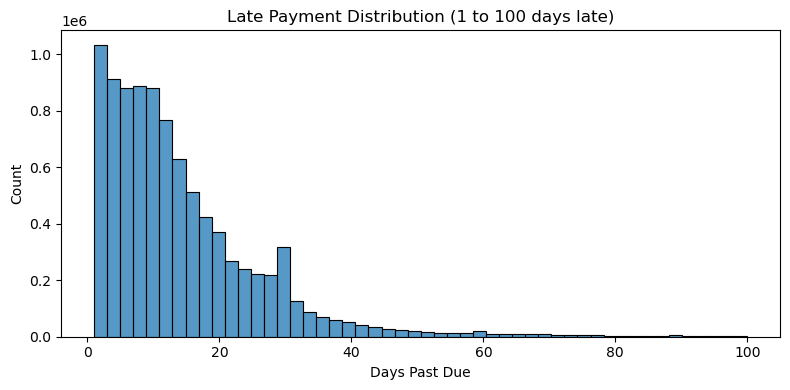

In [18]:
late_data = inst[
    (inst["days_past_due"] > 0) &
    (inst["days_past_due"] <= 100)
]["days_past_due"]

plt.figure(figsize=(8, 4))
sns.histplot(late_data, bins=50)
plt.title("Late Payment Distribution (1 to 100 days late)")
plt.xlabel("Days Past Due")
plt.tight_layout()
plt.show()

In [19]:
# amt_instalment = how much was REQUIRED to pay
# amt_payment    = how much was ACTUALLY paid
# Positive underpayment = paid LESS than required

inst["underpayment"] = inst["amt_instalment"] - inst["amt_payment"]

print("=== UNDERPAYMENT ===")
print(inst["underpayment"].describe().round(2))

total_amt = inst["underpayment"].notna().sum()
underpaid = (inst["underpayment"] > 0).sum()

print()
print("Installments with underpayment:",
      underpaid, f"({round(underpaid / total_amt * 100, 2)}%)")

=== UNDERPAYMENT ===
count    13602496.00
mean         -187.15
std         19106.73
min      -2630908.94
25%             0.00
50%             0.00
75%             0.00
max       2424726.41
Name: underpayment, dtype: float64

Installments with underpayment: 1295493 (9.52%)


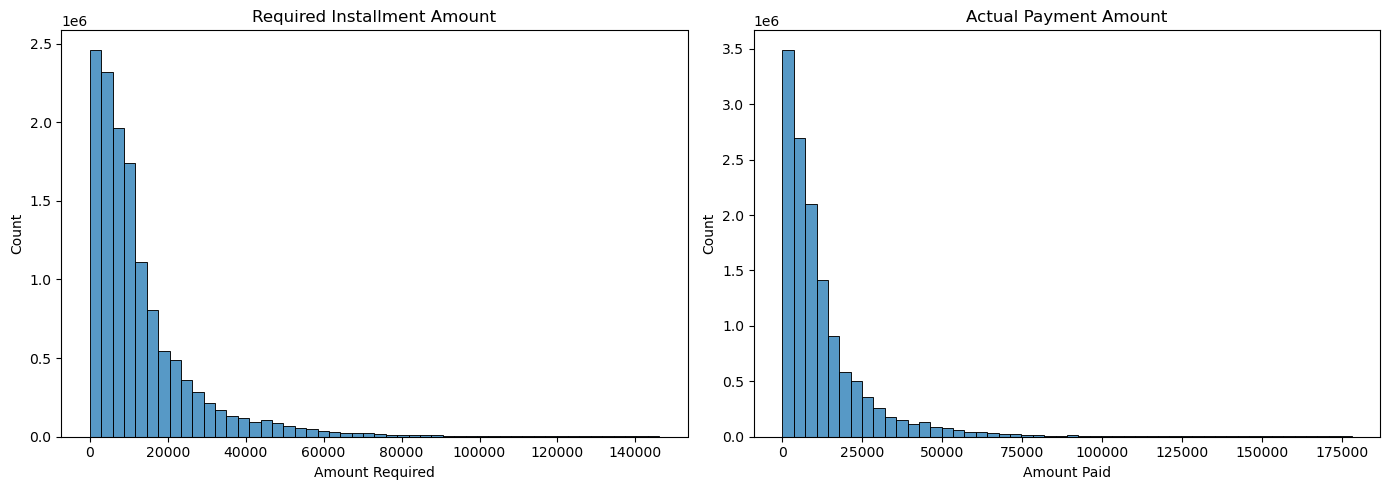

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

q99_i = inst["amt_instalment"].quantile(0.99)
sns.histplot(
    inst[inst["amt_instalment"] <= q99_i]["amt_instalment"],
    bins=50, ax=axes[0]
)
axes[0].set_title("Required Installment Amount")
axes[0].set_xlabel("Amount Required")

q99_p = inst["amt_payment"].quantile(0.99)
sns.histplot(
    inst[inst["amt_payment"] <= q99_p]["amt_payment"],
    bins=50, ax=axes[1]
)
axes[1].set_title("Actual Payment Amount")
axes[1].set_xlabel("Amount Paid")

plt.tight_layout()
plt.show()

## Step 8 — Relationship with Target

In [22]:
main_ids = set(df["sk_id_curr"])
inst_ids = set(inst["sk_id_curr"])

matched  = len(main_ids & inst_ids)
no_match = len(main_ids - inst_ids)

print("Have installment records:", matched,
      f"({round(matched / len(main_ids) * 100, 2)}%)")
print("No installment records  :", no_match,
      f"({round(no_match / len(main_ids) * 100, 2)}%)")

has_inst = df[df["sk_id_curr"].isin(inst_ids)]
no_inst  = df[~df["sk_id_curr"].isin(inst_ids)]

print()
print("Default rate WITH installment records :",
      round(has_inst["default"].mean() * 100, 2), "%")
print("Default rate WITHOUT records          :",
      round(no_inst["default"].mean() * 100, 2), "%")

Have installment records: 291643 (94.84%)
No installment records  : 15868 (5.16%)

Default rate WITH installment records : 8.19 %
Default rate WITHOUT records          : 5.98 %


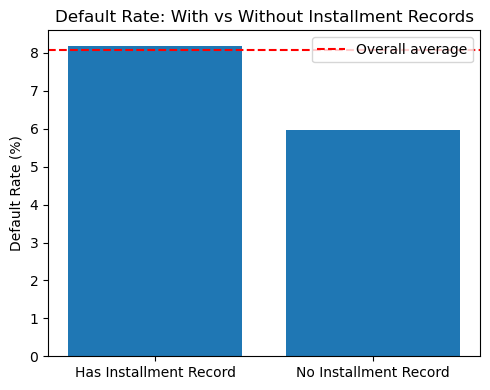

In [23]:
plt.figure(figsize=(5, 4))
plt.bar(
    ["Has Installment Record", "No Installment Record"],
    [has_inst["default"].mean() * 100,
     no_inst["default"].mean() * 100]
)
plt.title("Default Rate: With vs Without Installment Records")
plt.ylabel("Default Rate (%)")
plt.axhline(df["default"].mean() * 100, color="red",
            linestyle="--", label="Overall average")
plt.legend()
plt.tight_layout()
plt.show()

## Step 9 — Outlier Check

In [25]:
i_num   = inst.select_dtypes(include=np.number).columns.tolist()
excl_i  = ["sk_id_prev", "sk_id_curr",
           "num_instalment_version", "num_instalment_number"]
check_i = [c for c in i_num if c not in excl_i]

print(f"Checking {len(check_i)} columns\n")
print(f"{'Column':<35} {'1%':>12} {'99%':>12} {'Max':>15} {'Outlier?'}")
print("-" * 85)

outliers_i = []
for col in check_i:
    q01     = inst[col].quantile(0.01)
    q99     = inst[col].quantile(0.99)
    max_val = inst[col].max()
    is_out  = (max_val > q99 * 3) if q99 > 0 else (
               max_val > 100 if q99 == 0 else False)
    flag    = "YES" if is_out else "ok"
    if is_out:
        outliers_i.append(col)
    print(f"{col:<35} {q01:>12.2f} {q99:>12.2f} {max_val:>15.2f}  {flag}")

print()
print("Outlier columns:")
for c in outliers_i:
    print(" -", c)

Checking 6 columns

Column                                        1%          99%             Max Outlier?
-------------------------------------------------------------------------------------
days_instalment                         -2832.00       -21.00           -1.00  ok
days_entry_payment                      -2837.00       -28.00           -1.00  ok
amt_instalment                             13.28    146068.70      3771487.85  YES
amt_payment                                 3.78    178003.96      3771487.85  YES
days_past_due                             -18.00        60.00         3189.00  YES
underpayment                           -10821.38     19700.37      2424726.41  YES

Outlier columns:
 - amt_instalment
 - amt_payment
 - days_past_due
 - underpayment


## Step 10 — Aggregation and Correlation with Target

Installments aggregated shape: (339587, 8)

=== INSTALLMENT FEATURES — CORRELATION WITH DEFAULT ===
inst_late_payment_rate   -0.0521
inst_total_paid          -0.0244
inst_count               -0.0211
inst_avg_days_past_due   -0.0209
inst_max_days_past_due   -0.0071
inst_avg_underpayment     0.0293
inst_underpayment_rate    0.0626
Name: default, dtype: float64


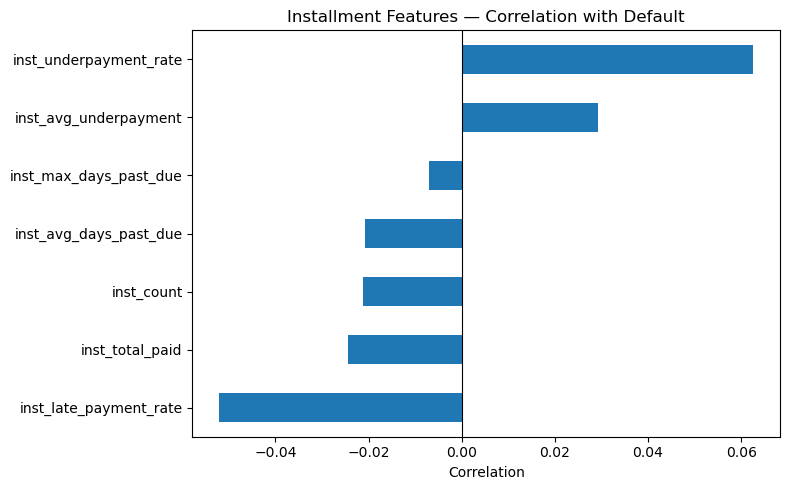

In [27]:
# Aggregate installments to applicant level
# Then check correlation with default to confirm signal strength

inst_agg = inst.groupby("sk_id_curr").agg(
    inst_count             = ("sk_id_prev", "count"),
    inst_avg_days_past_due = ("days_past_due", "mean"),
    inst_max_days_past_due = ("days_past_due", "max"),
    inst_late_payment_rate = ("days_past_due",
                              lambda x: (x > 0).sum() / len(x)),
    inst_avg_underpayment  = ("underpayment", "mean"),
    inst_underpayment_rate = ("underpayment",
                              lambda x: (x > 0).sum() / len(x)),
    inst_total_paid        = ("amt_payment", "sum"),
).reset_index()

print("Installments aggregated shape:", inst_agg.shape)
print()

# Merge with main dataset
df_inst = df.merge(inst_agg, on="sk_id_curr", how="left")

# Check correlation with default
inst_feat_cols = [c for c in inst_agg.columns if c != "sk_id_curr"]
corr_inst = (df_inst[inst_feat_cols + ["default"]]
             .corr()["default"]
             .drop("default"))

print("=== INSTALLMENT FEATURES — CORRELATION WITH DEFAULT ===")
print(corr_inst.sort_values().round(4))

plt.figure(figsize=(8, 5))
corr_inst.sort_values().plot(kind="barh")
plt.title("Installment Features — Correlation with Default")
plt.xlabel("Correlation")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## Observations

- 13,605,401 records, 8 columns. Average 40.06 payment records per applicant.
- Almost no missing values — only 0.02%.
- 94.84% of applicants have installment records.
- 68.44% of payments are technically late but average lateness is only 8.79 days.
- People who default completely stop paying — so having many records means active borrower.
  This explains why late_payment_rate shows a counterintuitive negative correlation.
- Only 9.52% of installments have underpayment (paying less than required).
- inst_underpayment_rate is the strongest signal — paying less than required indicates
  financial stress and correlates positively with default (+0.063).
- inst_avg_underpayment also shows positive correlation (+0.029).
- amt_instalment and amt_payment both have extreme outliers — max around 3.7M
  vs 99th percentile around 150K — cap at 99th percentile.